# Аналіз датасету HW-NAS-Bench

Мета notebook: перевірити структуру підготовлених CSV-файлів, оцінити доступні метрики та визначити, які поля можна використовувати для побудови моделі прогнозування latency.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
NASBENCH201_PATH = PROJECT_ROOT / "data" / "processed" / "hwnasbench_nasbench201.csv"
FBNET_PATH = PROJECT_ROOT / "data" / "processed" / "hwnasbench_fbnet.csv"

NASBENCH201_PATH, FBNET_PATH

(WindowsPath('P:/pythonProject5/data/processed/hwnasbench_nasbench201.csv'),
 WindowsPath('P:/pythonProject5/data/processed/hwnasbench_fbnet.csv'))

## Завантаження даних

In [3]:
nasbench201 = pd.read_csv(NASBENCH201_PATH)
fbnet = pd.read_csv(FBNET_PATH)

print("NASBench201 shape:", nasbench201.shape)
print("FBNet shape:", fbnet.shape)

NASBench201 shape: (281250, 17)
FBNet shape: (1125, 14)


In [4]:
nasbench201.head()

,search_space,dataset,arch_id,device,latency,energy,arithmetic_intensity,arch_name,base_channels,num_cells,num_classes,arch_str,op_count_avg_pool_3x3,op_count_nor_conv_1x1,op_count_nor_conv_3x3,op_count_skip_connect,op_count_none
0,nasbench201,cifar10,0,edgegpu,5.807419,24.226614,NaN,infer.tiny,16,5,10,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,1,2,0,3,0
1,nasbench201,cifar10,0,raspi4,10.481977,NaN,NaN,infer.tiny,16,5,10,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,1,2,0,3,0
2,nasbench201,cifar10,0,edgetpu,0.957181,NaN,NaN,infer.tiny,16,5,10,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,1,2,0,3,0
3,nasbench201,cifar10,0,pixel3,3.605850,NaN,NaN,infer.tiny,16,5,10,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,1,2,0,3,0
4,nasbench201,cifar10,0,eyeriss,3.645620,0.687283,6.289298,infer.tiny,16,5,10,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,1,2,0,3,0


In [5]:
fbnet.head()

,search_space,block_id,device,latency,energy,block_name,input_h,input_w,cin,cout,expansion,kernel,stride,group
0,fbnet,0,edgegpu,0.737254,5.922727,ConvBlock_H112_W112_Cin16_Cout16_exp1_kernel3_...,112.0,112.0,16.0,16.0,1.0,3.0,1.0,1.0
1,fbnet,1,edgegpu,1.036761,8.942475,ConvBlock_H112_W112_Cin16_Cout16_exp1_kernel3_...,112.0,112.0,16.0,16.0,1.0,3.0,1.0,2.0
2,fbnet,2,edgegpu,1.116978,10.310521,ConvBlock_H112_W112_Cin16_Cout16_exp3_kernel3_...,112.0,112.0,16.0,16.0,3.0,3.0,1.0,1.0
3,fbnet,3,edgegpu,1.686460,17.140545,ConvBlock_H112_W112_Cin16_Cout16_exp6_kernel3_...,112.0,112.0,16.0,16.0,6.0,3.0,1.0,1.0
4,fbnet,4,edgegpu,1.060066,9.257464,ConvBlock_H112_W112_Cin16_Cout16_exp1_kernel5_...,112.0,112.0,16.0,16.0,1.0,5.0,1.0,1.0


## Доступні датасети, пристрої та метрики

In [6]:
nasbench201[["dataset", "device"]].drop_duplicates().sort_values(["dataset", "device"])

,dataset,device
187500,ImageNet16-120,edgegpu
187502,ImageNet16-120,edgetpu
187504,ImageNet16-120,eyeriss
187505,ImageNet16-120,fpga
187503,ImageNet16-120,pixel3
187501,ImageNet16-120,raspi4
0,cifar10,edgegpu
2,cifar10,edgetpu
4,cifar10,eyeriss
5,cifar10,fpga


In [7]:
nasbench201[["latency", "energy", "arithmetic_intensity"]].isna().sum().to_frame("missing_count")

,missing_count
latency,0
energy,140625
arithmetic_intensity,234375


Latency доступна для всіх записів, тому вона використовується як основна ціль прогнозування. Energy доступна лише для частини пристроїв, тому її доцільно розглядати як додаткову задачу.

## Перевірка невалідних значень latency

In [8]:
invalid_latency = (nasbench201["latency"] <= 0).sum()
valid_latency = (nasbench201["latency"] > 0).sum()

print("Invalid latency rows:", invalid_latency)
print("Valid latency rows:", valid_latency)

Invalid latency rows: 14097
Valid latency rows: 267153


Для навчання моделі використовуються тільки записи з `latency > 0`, оскільки значення `-1` означають невалідний або відсутній вимір.

## Описова статистика latency

In [9]:
valid_nasbench201 = nasbench201[nasbench201["latency"] > 0].copy()
valid_nasbench201["latency"].describe()

count    267153.000000
mean          7.384110
std           9.796494
min           0.003277
25%           1.701163
50%           4.572960
75%           7.066580
max          98.887521
Name: latency, dtype: float64

In [10]:
valid_nasbench201.groupby("device")["latency"].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
device,,,,,,,,
edgegpu,46875.0,5.052,1.528,0.501,4.138,5.314,6.141,11.693
edgetpu,32778.0,1.040,0.364,0.347,0.772,0.992,1.304,2.587
eyeriss,46875.0,4.137,2.398,0.423,1.652,4.629,6.106,10.530
fpga,46875.0,2.866,1.576,0.284,1.411,2.906,4.058,8.679
pixel3,46875.0,9.103,6.847,0.003,3.500,7.350,13.263,43.882
raspi4,46875.0,20.199,16.054,0.011,6.606,15.693,28.754,98.888


## Розподіл latency за пристроями

<Figure size 1000x500 with 0 Axes>

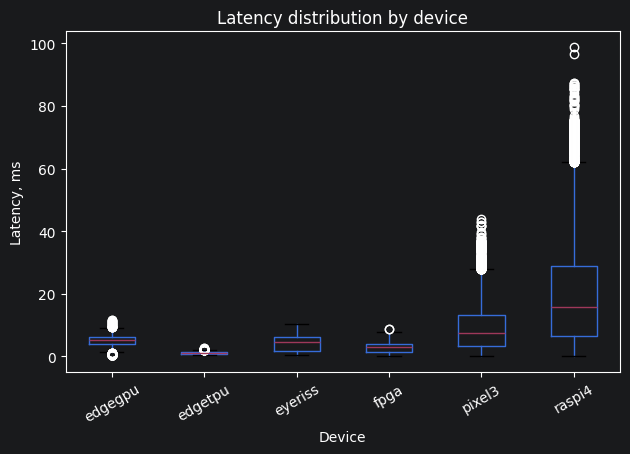

In [11]:
plt.figure(figsize=(10, 5))
valid_nasbench201.boxplot(column="latency", by="device", grid=False)
plt.title("Latency distribution by device")
plt.suptitle("")
plt.xlabel("Device")
plt.ylabel("Latency, ms")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Ознаки архітектури NASBench201

In [12]:
architecture_columns = [column for column in nasbench201.columns if column.startswith("op_count_")]
valid_nasbench201[architecture_columns].describe().round(3)

,op_count_avg_pool_3x3,op_count_nor_conv_1x1,op_count_nor_conv_3x3,op_count_skip_connect,op_count_none
count,267153.000,267153.000,267153.000,267153.000,267153.000
mean,1.204,1.207,1.207,1.220,1.162
std,0.984,0.984,0.984,0.984,0.971
min,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.000,0.000,0.000
50%,1.000,1.000,1.000,1.000,1.000
75%,2.000,2.000,2.000,2.000,2.000
max,6.000,6.000,6.000,6.000,6.000


## Висновок

- Основний CSV `hwnasbench_nasbench201.csv` містить достатній обсяг даних для навчання регресійної моделі.
- Основна ціль прогнозування: `latency`.
- Для навчання треба фільтрувати записи з `latency <= 0`.
- Категоріальні ознаки: `dataset`, `device`.
- Числові ознаки: параметри конфігурації та кількості операцій в архітектурі.